In [20]:
#POR:DIEGO GARCIA IBARRA
#comenzamos por instalar lo necesario para poder usar yolo 
!pip install --user torch torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [2]:
!pip install --user opencv-python py-cpuinfo ultralytics-thop

In [3]:
!pip install ultralytics --no-deps --no-cache-dir --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 10.6 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.155
    Uninstalling ultralytics-8.3.155:
      Successfully uninstalled ultralytics-8.3.155


In [4]:
!pip install --user opencv-python-headless --force-reinstall --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 103.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 105.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.0
    Uninstalling numpy-2.3.0:
      Successfully uninstalled numpy-2.3.0
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scipy 1.14.1 requires numpy<2.3,>=1.2


0: 480x640 1 person, 1 cup, 1 apple, 1 orange, 1 pizza, 2 laptops, 1 keyboard, 25.4ms
Speed: 3.2ms preprocess, 25.4ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
🧭 Objeto: laptop → Posición estimada: X=55.1cm, Y=92.7cm, Z=0cm
🧭 Objeto: person → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: laptop → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: apple → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: cup → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: keyboard → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: pizza → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: orange → Posición estimada: X=55.1, Y=92.7, Z=0
🧭 Objeto: laptop → Posición estimada: X=55.1, Y=92.7, Z=0


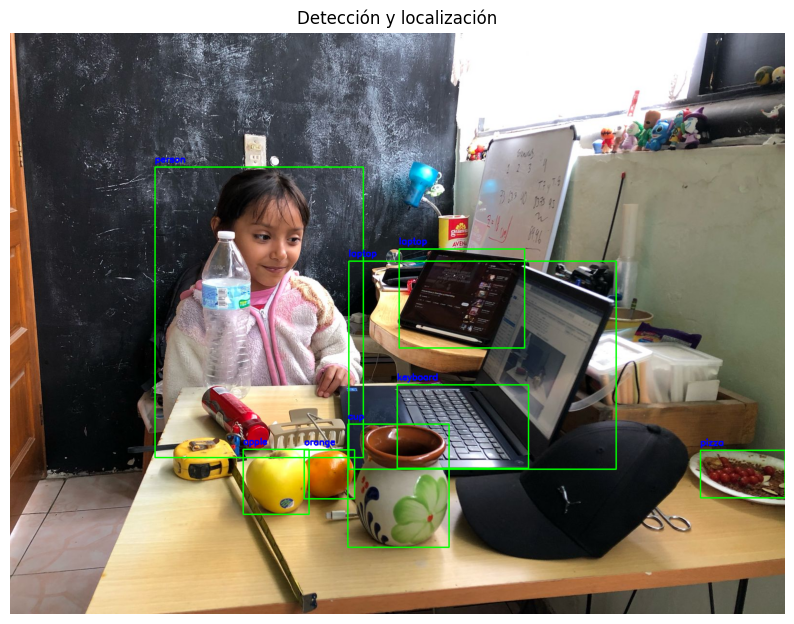

In [19]:
# A PARTIR DE AQUI COMIENZA EL CODIGO PARA ANALIZAR UNA SOLA IMAGEN 
import cv2 #PARA CAMBIAR EL FORATO DE
from ultralytics import YOLO #IMPORTAMOS YOLO 
import numpy as np
import matplotlib.pyplot as plt #importamos esto para visualizar las imagenes en este entorno 

# --- Cargar modelo YOLOv8 (nano o el que se prefiera) ---
modelo = YOLO("yolov8n.pt")  # Asegúrate de tener el modelo descargado

# --- Ruta de la imagen a procesar (una de las 5 capturadas) ---
ruta_imagen = "im_8.jpeg"  # ← Cambiar por la imagen correspondiente
imagen = cv2.imread(ruta_imagen)

# --- Procesar imagen con YOLO ---
resultados = modelo(imagen)[0]

# --- Función de ejemplo (vacía) para convertir a unidades reales ---
def convertir_a_coordenadas_reales(x_px, y_px):
    # Este paso depende de la calibración física de la cámara
    # Aquí debes poner tu fórmula si conoces escala o matriz de calibración
    # Calcular el centro del objeto (en píxeles)
    cx, cy = int(x), int(y) #ESTO LO HACE RESPECTO AL ORIGEN QUE SE ENCUENTRA EN LA ESQUINA SUPERIOR IZQUIERDA DE LA IMAGEN

# Convertir a coordenadas reales
    FACTOR_ESCALA_CM_POR_PX = 0.1
    x_m = cx * FACTOR_ESCALA_CM_POR_PX
    y_m = cy * FACTOR_ESCALA_CM_POR_PX
    z_m = 0  # Profundidad no estimada
    return x_cm, y_cm

print(f"🧭 Objeto: {clase_nombre} → Posición estimada: X={x_m:.1f}cm, Y={y_m:.1f}cm, Z={z_m}cm")

    
   # return 0, 0  # ← Placeholder

# --- Dibujar resultados ---
for box in resultados.boxes:
    x, y, w, h = box.xywh[0].tolist()
    clase_id = int(box.cls[0])
    clase_nombre = modelo.names[clase_id]

    # Centro del objeto
    cx, cy = int(x), int(y)

    # Conversión (a completar tú según tu contexto)
    x_m, y_m = convertir_a_coordenadas_reales(cx, cy)

    # Coordenada Z también debería estimarse si es 3D
    z_m = 0

    print(f"🧭 Objeto: {clase_nombre} → Posición estimada: X={x_m}, Y={y_m}, Z={z_m}")

      # Dibujar la caja en la imagen
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cv2.rectangle(imagen, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(imagen, clase_nombre, (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# --- Mostrar imagen con matplotlib ---
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(imagen_rgb)
plt.axis('off')
plt.title("Detección y localización")
plt.show()



🔍 Se encontraron 6 imágenes para procesar.

0: 384x640 1 sports ball, 1 bottle, 1 chair, 1 laptop, 1 remote, 1 vase, 22.7ms
Speed: 3.2ms preprocess, 22.7ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

📸 Imagen: im_1.jpeg
🧭 Objeto: bottle → Posición estimada: X=42.3cm, Y=30.3cm, Z=0cm
🧭 Objeto: laptop → Posición estimada: X=76.6cm, Y=30.2cm, Z=0cm
🧭 Objeto: chair → Posición estimada: X=14.5cm, Y=72.6cm, Z=0cm
🧭 Objeto: remote → Posición estimada: X=59.4cm, Y=53.6cm, Z=0cm
🧭 Objeto: vase → Posición estimada: X=122.5cm, Y=42.3cm, Z=0cm
🧭 Objeto: sports ball → Posición estimada: X=117.0cm, Y=50.3cm, Z=0cm

0: 480x640 1 bottle, 1 laptop, 1 vase, 23.1ms
Speed: 2.1ms preprocess, 23.1ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

📸 Imagen: im_4.jpeg
🧭 Objeto: bottle → Posición estimada: X=36.4cm, Y=52.8cm, Z=0cm
🧭 Objeto: vase → Posición estimada: X=120.8cm, Y=65.5cm, Z=0cm
🧭 Objeto: laptop → Posición estimada: X=73.9cm, Y=53.5cm, Z=0cm

0: 480x640 1 

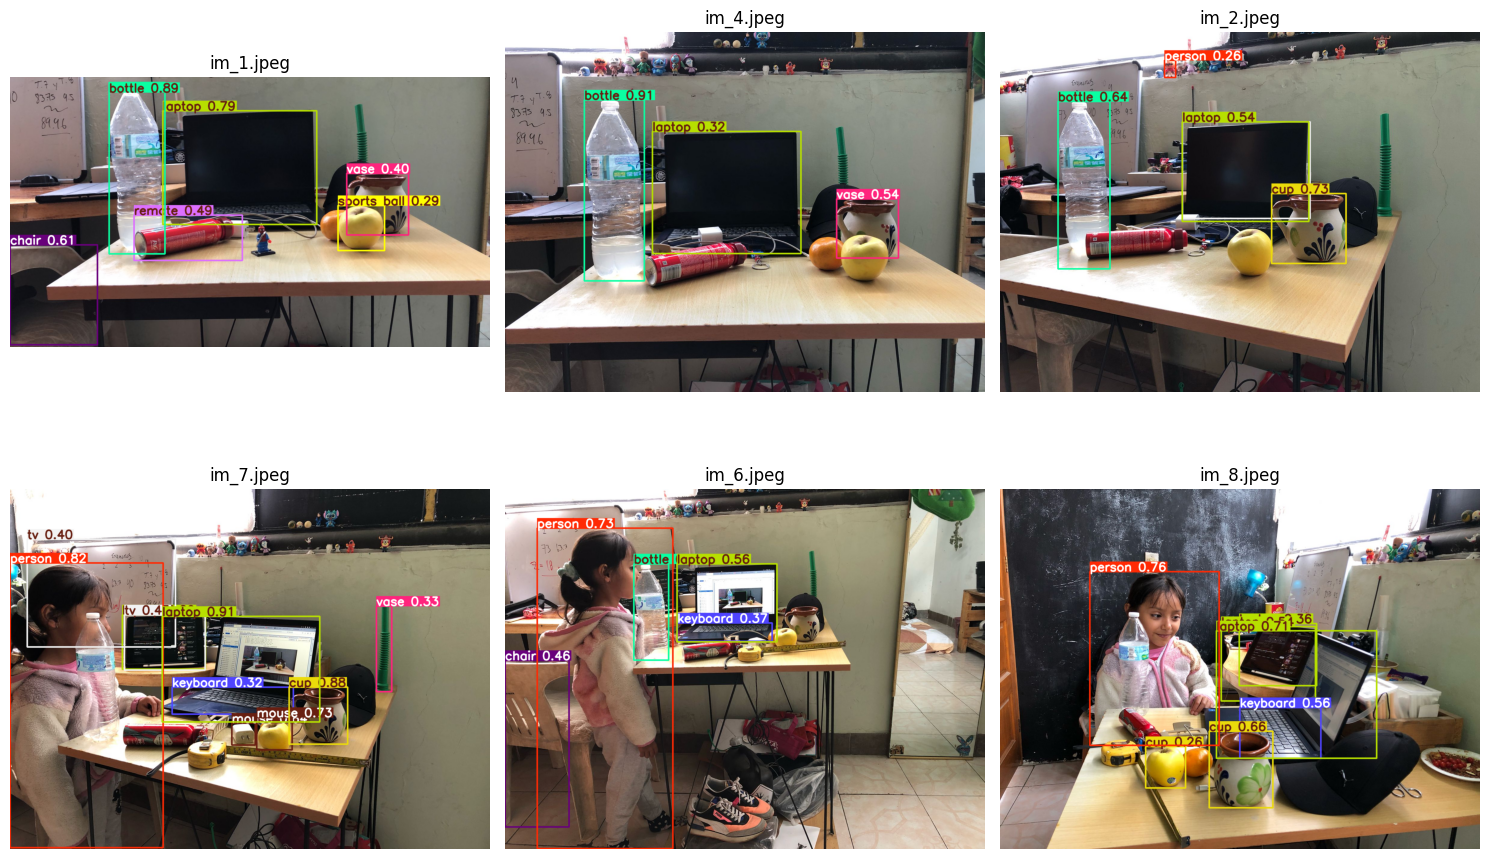

In [15]:
#AHORA PARA ANALIZAR UN CONJUNTO DE  IMAGENES VAMOS A CREAR UNA LISTA PARA FILTRAR LAS IMAGENESES ESPECIFICAS DEL REPOSITORIO
#USAREMOS UN for PARA RECORER LAS IMAGENES Y A PLICAR LA INFERENCIA DE YOLO EN CADA UNA DE ELLAS 
#POSTERIORMENTE LAS VAMOS A GUARDAR Y LAS PRESENTAREMOS EN UNA CUADRICULA EN EL MISMO NOTBOOK
import cv2 #PARA CARGAR IMAGENES Y CONVERTIR A FORMATO DE COLOR 
import os #PARA MANIPULAR RUTAS Y LISTAR ARCHIVOS DEL SISTEMA
import math
import matplotlib.pyplot as plt #PARA GRAFICAR LASIMAGENES ANOTADAS DENTRO DE ESTE ENTORNO 
from ultralytics import YOLO #IMPORTAMOS YOLO asumiendo que usas ultralytics YOLOv8

modelo = YOLO("yolov8n.pt")  #Carga la versión YOLOv8 nano (la más ligera). Puedes cambiar por "yolov8s.pt", "yolov8m.pt", etc.
ruta_carpeta = "." #NOS FIJAMOS AL  DIRECTORIO ACTUAL
extensiones_validas = ('im_1.jpeg', 'im_2.jpeg', 'im_4.jpeg', 'im_6.jpeg', 'im_7.jpeg','im_8.jpeg') #FILTRAMOS LASIMAGENES QUE VASMOSAANALIZAR
print(f"🔍 Se encontraron {len(lista_imagenes)} imágenes para procesar.")
lista_imagenes = [f for f in os.listdir(ruta_carpeta) if f.lower().endswith(extensiones_validas)]

FACTOR_ESCALA_CM_POR_PX = 0.1  # ← Ajusta este valor según tu cámara
#EL FACTOR DE ESCALA SE DEFINE COMO: tamaño_real_en_cm / tamaño_imagen_en_pixeles
imagenes_anotadas = [] #GENERAMOS UNA LISTA BACIA PARA GUARDAR LAS IMAGENES ANALIZADAS

for nombre in lista_imagenes:
    ruta_imagen = os.path.join(ruta_carpeta, nombre) #CONSTRUYE UNA RUTA DIRECTA PARA CADA  IMAGEN
    imagen = cv2.imread(ruta_imagen) #CARGA LA IMAGEN A OpenCV
    if imagen is None:
        print(f"⚠️ No se pudo cargar: {ruta_imagen}") #AVISA SI NO SE PUDO CARGAR UNA IMAGEN Y LA SALTA 
        continue

    imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB) # CONVERTIMOS A FORMATO RGB PARA matplotlib
    resultado = modelo(imagen_rgb)[0] #EJECUTA LA INFERENCIA 
    imagen_anotada = resultado.plot() #OBTIENE LAS IMAGENES CON LAS DETECCIONES ANOTADAS 
    imagenes_anotadas.append((nombre, imagen_anotada)) #GUARDA LAS IMAGENES ANOTADAS CON SU NOMBRE 

    print(f"\n📸 Imagen: {nombre}")
    for box in resultado.boxes: #ESTO ITERA SOBRE TODA LAS  CAJAS DETECTADAS POR YOLO EN UNA IMAGEN 
        x, y, w, h = box.xywh[0].tolist() # Extrae las coordenadas de la caja detectada en formato (centro_x, centro_y, ancho, alto). ESTO RESPECTO AL ORIGEN QUE ES LA ESQUINA SUPERIOR IZQUIERDA DE LA IMAGEN
        clase_id = int(box.cls[0])
        nombre_clase = modelo.names[clase_id]  #ESTAS ULTIMAS DOS LINEAS Obtienen el ID de la clase detectada (ej. 0 = "person", 1 = "bicycle", etc.)
#Luego accede al nombre humano de esa clase, usando modelo.names.

        # Centro en píxeles
        cx, cy = int(x), int(y) #Extrae el centro del objeto en píxeles, redondeado a enteros. 

        # Estimar coordenadas reales
        x_cm = cx * FACTOR_ESCALA_CM_POR_PX    #Convierte esas coordenadas en píxeles a unidades reales, usando un factor de escala definido 
        y_cm = cy * FACTOR_ESCALA_CM_POR_PX
        z_cm = 0  # ← Si quieres estimar Z necesitas más datos

        print(f"🧭 Objeto: {nombre_clase} → Posición estimada: X={x_cm:.1f}cm, Y={y_cm:.1f}cm, Z={z_cm}cm")

# Mostrar las imágenes anotadas en cuadrícula
cols = 3 #SE DEFINE EL  NUMERO DE COLUMNAS 
rows = math.ceil(len(imagenes_anotadas) / cols) #SE CALCULA EL NUMERO DE FILAS
plt.figure(figsize=(15, 5 * rows)) #CREA UNA FUGURA DE matplotlib

for i, (nombre, imagen) in enumerate(imagenes_anotadas):  #recorre todas las imágenes procesadas.
    plt.subplot(rows, cols, i + 1) # ubica la imagen actual en su lugar de la cuadrícula.
    plt.imshow(imagen) #muestra la imagen.
    plt.axis('off') #quita los ejes (para que no se vean números feos).
    plt.title(nombre) #escribe el nombre del archivo arriba de cada imagen.

plt.tight_layout() #hace que las imágenes no se encimen ni se salgan.
print(f"🖼️ Total de imágenes anotadas: {len(imagenes_anotadas)}")
plt.show() #muestra toda la cuadrícula en el notebook.




In [ ]:
#RESUMEN: 
#En la primera prueba donde se analiza una sola imagen podemos observar que la clasificacio de yolo
#es buena aunque no completamente precisa, las distancias calculadas para los objetos  van a depender del factor de 
#conversion que se utilice
#estimar la profundidad (z) no es un problema trivial asi que por tiempo de entrega decidimos no entrarle.